# Quantitative Trading Strategy: Nasdaq-100 Momentum

## Objective

This project develops and evaluates a simple momentum trading strategy based on the 50-day moving average of the QQQ ETF.

## Methodology

- Download historical market data using yfinance.
- Calculate daily returns.
- Build a moving-average trading signal.
- Backtest the strategy.
- Compare its performance with a buy-and-hold benchmark.
- Evaluate total return, annualized volatility, Sharpe ratio and maximum drawdown.

## Tools

Python, Pandas, NumPy, Matplotlib, yfinance.

## Disclaimer

This project is for educational purposes only and does not constitute investment advice.

In [1]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = yf.download(
    "QQQ",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
                  )
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2015-01-02,94.561150,95.718586,94.101847,95.314405,31314600
2015-01-05,93.174049,94.258003,92.907653,94.147768,36521300
2015-01-06,91.924736,93.467992,91.511367,93.311831,66205500
2015-01-07,93.109749,93.330212,92.310560,92.531031,37577400
2015-01-08,94.891853,95.075571,93.798712,93.899759,40212600


In [6]:
prices = data["Close"]
prices = prices.squeeze()
prices.head()

,QQQ
Date,
2015-01-02,94.561150
2015-01-05,93.174049
2015-01-06,91.924736
2015-01-07,93.109749
2015-01-08,94.891853


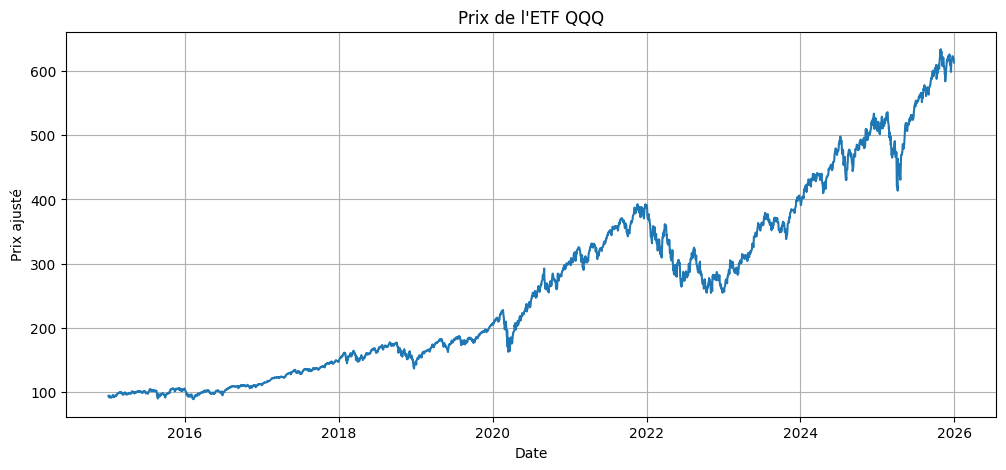

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(prices)
plt.title("Prix de l'ETF QQQ")
plt.xlabel("Date")
plt.ylabel("Prix ajusté")
plt.grid()
plt.show()

Let's start now the quantitative aspect of our project, we will calculate a mobile mean at 50 days :
- If price > mean : we invest
- If price < mean : we stay in cash

In [10]:
data_strategy = pd.DataFrame()
data_strategy["Price"] = prices
data_strategy["MA50"] = (
    data_strategy["Price"]
    .rolling(window=50)
    .mean()
)
data_strategy.head(60)

,Price,MA50
Date,,
2015-01-02,94.561150,NaN
2015-01-05,93.174049,NaN
2015-01-06,91.924736,NaN
2015-01-07,93.109749,NaN
2015-01-08,94.891853,NaN
2015-01-09,94.267212,NaN
2015-01-12,93.284294,NaN
2015-01-13,93.256706,NaN
2015-01-14,92.742317,NaN


In [13]:
data_strategy["Signal"] = np.where(
    data_strategy["Price"] > data_strategy["MA50"], 1, 0
)

In [14]:
data_strategy.tail()

,Price,MA50,Signal
Date,,,
2025-12-24,622.460266,612.965096,1
2025-12-26,622.420288,613.412938,1
2025-12-29,619.407410,613.844960,1
2025-12-30,617.970764,614.169734,1
2025-12-31,612.862854,614.240706,0


In [16]:
data_strategy["Market_Return"] = (
    data_strategy["Price"].pct_change()
)

In [17]:
data_strategy["Strategy_Return"] = (
    data_strategy["Signal"].shift(1)
    * data_strategy["Market_Return"]
)

In [18]:
data_strategy = data_strategy.dropna()

In [19]:
data_strategy["Buy_Hold"] = (
    1 + data_strategy["Market_Return"]
).cumprod()

data_strategy["Momentum_Strategy"] = (
    1 + data_strategy["Strategy_Return"]
).cumprod()

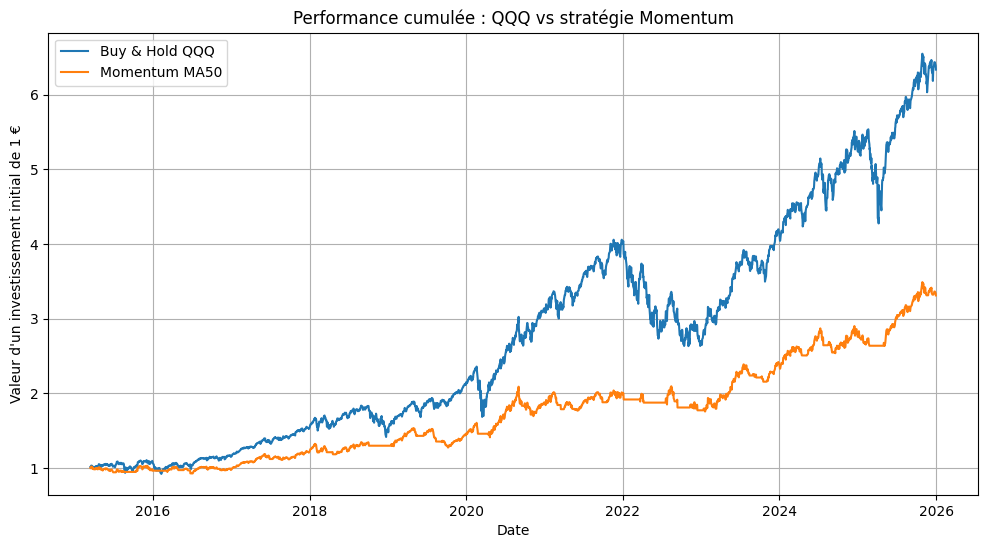

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    data_strategy.index,
    data_strategy["Buy_Hold"],
    label="Buy & Hold QQQ"
)

plt.plot(
    data_strategy.index,
    data_strategy["Momentum_Strategy"],
    label="Momentum MA50"
)

plt.title("Performance cumulée : QQQ vs stratégie Momentum")
plt.xlabel("Date")
plt.ylabel("Valeur d'un investissement initial de 1 €")

plt.legend()
plt.grid()

plt.show()

In [21]:
buy_hold_total = (
    data_strategy["Buy_Hold"].iloc[-1] - 1
)

momentum_total = (
    data_strategy["Momentum_Strategy"].iloc[-1] - 1
)

print("Rendement Buy & Hold :", round(buy_hold_total * 100, 2), "%")
print("Rendement Momentum :", round(momentum_total * 100, 2), "%")

Rendement Buy & Hold : 533.35 %
Rendement Momentum : 231.08 %


In [22]:
volatility_buy_hold = (
    data_strategy["Market_Return"]
    .std() * np.sqrt(252)
)
volatility_momentum = (
    data_strategy["Strategy_Return"]
    .std() * np.sqrt(252)
)
print(
    "Volatilité Buy & Hold :",
    round(volatility_buy_hold * 100, 2),
    "%"
)

print(
    "Volatilité Momentum :",
    round(volatility_momentum * 100, 2),
    "%"
)

Volatilité Buy & Hold : 22.09 %
Volatilité Momentum : 13.92 %


In [23]:
annual_return_buy_hold = (
    data_strategy["Market_Return"].mean() * 252
)

annual_return_momentum = (
    data_strategy["Strategy_Return"].mean() * 252
)

sharpe_buy_hold = (
    annual_return_buy_hold / volatility_buy_hold
)

sharpe_momentum = (
    annual_return_momentum / volatility_momentum
)

print(
    "Sharpe Buy & Hold :",
    round(sharpe_buy_hold, 2)
)

print(
    "Sharpe Momentum :",
    round(sharpe_momentum, 2)
)

Sharpe Buy & Hold : 0.89
Sharpe Momentum : 0.87


In [24]:
def max_drawdown(performance):
  peak = performance.cummax()
  drawdown = performance / peak -1
  return drawdown.min()

In [25]:
dd_buy_hold = max_drawdown(
    data_strategy["Buy_Hold"]
)

dd_momentum = max_drawdown(
    data_strategy["Momentum_Strategy"]
)

print(
    "Max Drawdown Buy & Hold :",
    round(dd_buy_hold * 100, 2),
    "%"
)

print(
    "Max Drawdown Momentum :",
    round(dd_momentum * 100, 2),
    "%"
)

Max Drawdown Buy & Hold : -35.12 %
Max Drawdown Momentum : -18.87 %


In [26]:
results = pd.DataFrame({
    "Strategy": [
        "Buy & Hold QQQ",
        "Momentum MA50"
    ],
    "Total Return": [
        buy_hold_total,
        momentum_total
    ],
    "Volatility": [
        volatility_buy_hold,
        volatility_momentum
    ],
    "Sharpe Ratio": [
        sharpe_buy_hold,
        sharpe_momentum
    ],
    "Max Drawdown": [
        dd_buy_hold,
        dd_momentum
    ]
})

results

,Strategy,Total Return,Volatility,Sharpe Ratio,Max Drawdown
0,Buy & Hold QQQ,5.333464,0.220855,0.886043,-0.351187
1,Momentum MA50,2.310752,0.139227,0.867506,-0.188711


In [27]:
results_display = results.copy()

results_display["Total Return"] = (
    results_display["Total Return"] * 100
).round(2).astype(str) + "%"

results_display["Volatility"] = (
    results_display["Volatility"] * 100
).round(2).astype(str) + "%"

results_display["Max Drawdown"] = (
    results_display["Max Drawdown"] * 100
).round(2).astype(str) + "%"

results_display["Sharpe Ratio"] = (
    results_display["Sharpe Ratio"].round(2)
)

results_display

,Strategy,Total Return,Volatility,Sharpe Ratio,Max Drawdown
0,Buy & Hold QQQ,533.35%,22.09%,0.89,-35.12%
1,Momentum MA50,231.08%,13.92%,0.87,-18.87%


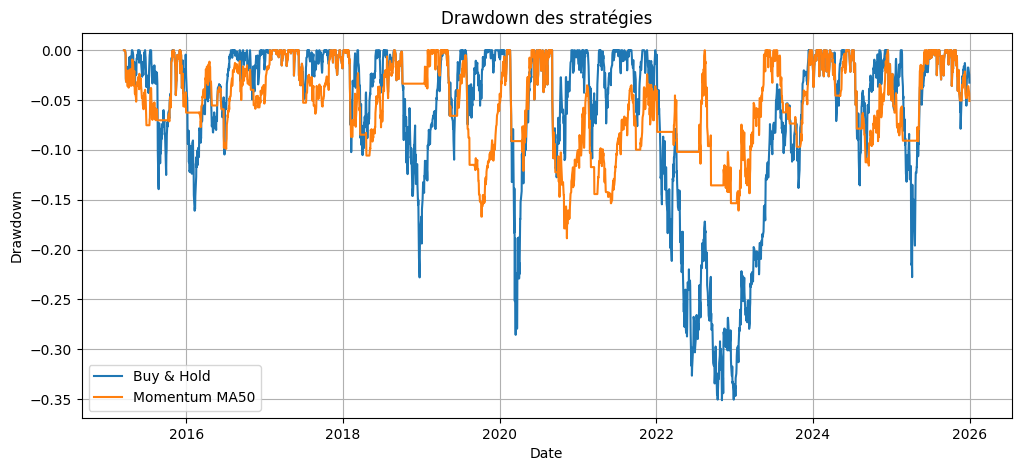

In [28]:
def drawdown_series(performance):
    peak = performance.cummax()
    return performance / peak - 1

dd_buy_hold_series = drawdown_series(
    data_strategy["Buy_Hold"]
)

dd_momentum_series = drawdown_series(
    data_strategy["Momentum_Strategy"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    dd_buy_hold_series,
    label="Buy & Hold"
)

plt.plot(
    dd_momentum_series,
    label="Momentum MA50"
)

plt.title("Drawdown des stratégies")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.grid()

plt.show()